# Multi-Source Illumination

An `NSQScene` can hold any number of sources simultaneously. All sources launch
rays in the same trace, and every ray carries flux proportional to its source's
`total_flux`. This makes it straightforward to model:

- **Multi-point LED arrays** — many PointSources at different positions
- **Off-axis illumination** — sources tilted relative to the optical axis
- **Field uniformity analysis** — sources spanning a range of field angles
- **Mixed spectral sources** — sources with different spectra

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from optiland.coordinate_system import CoordinateSystem
from optiland.nonsequential import (
    NSQScene, Spectrum,
    PointSourceConfig, CollimatedSourceConfig, ExtendedSourceConfig,
    IrradianceDetectorConfig,
    LensConfig,
)

spec_w = Spectrum(wavelengths=np.array([0.45, 0.55, 0.65]),
                  weights=np.array([1.0, 1.0, 1.0]))
spec_green = Spectrum.monochromatic(0.55)

# Two lenses are reused throughout. Both are N-BK7 biconvex singlets; what
# matters for illumination work is where their focal points sit, so both
# prescriptions are reduced to numbers here once.
#
#   condenser  r1=40, r2=-40, t=5  ->  f = 39.41 mm, front focus z = -37.73
#   singlet    r1=50, r2=-50, t=5  ->  f = 49.05 mm, rear  focus z = +52.38
#
# A source placed at a lens's FRONT focal point leaves it collimated. That is
# the whole trick behind a condenser, and putting the source anywhere else is
# the most common reason an illumination model does not do what was intended.
CONDENSER = LensConfig(r1=40, r2=-40, thickness=5, material='N-BK7',
                       front_aperture_radius=15.0)
CONDENSER_FRONT_FOCUS = -37.73

SINGLET = LensConfig(r1=50, r2=-50, thickness=5, material='N-BK7',
                     front_aperture_radius=15.0)
SINGLET_REAR_FOCUS = 52.38


## 1. LED Array — Multiple PointSources

Model a 3×3 LED array with 2 mm pitch. Each LED is a `PointSource` with a narrow
emission cone. (A true Lambertian die would emit over the full hemisphere with
cosine weighting; `ExtendedSourceConfig` models that case, and a finite die size
as well.)

Two numbers decide whether this scene means anything.

**Where the array sits.** To collimate the array the LEDs go at the condenser's
**front focal point**, z = −37.73 mm. Each LED then leaves the lens as its own
collimated bundle, tilted by `atan(x / f)` — 2.9° for the outermost LEDs at
±2 mm. Put the array at z = −20 instead, well inside the focal length, and the
lens forms a virtual image: the light still diverges and nothing is collimated,
whatever the comment says.

**How wide the cone is.** From 37.73 mm away, the 15 mm lens semi-diameter
subtends `atan(15 / 37.73)` = 21.7°. A 20° half-angle fills the aperture without
spilling much light past the glass — rays that miss the lens reach the detector
unfocused and quietly corrupt the uniformity numbers computed in the next
section.


Total sources    : 9
Total flux in    : 9.00 W
Flux detected    : 7.092 W (79% collected)
Flux escaped     : 1.908 W


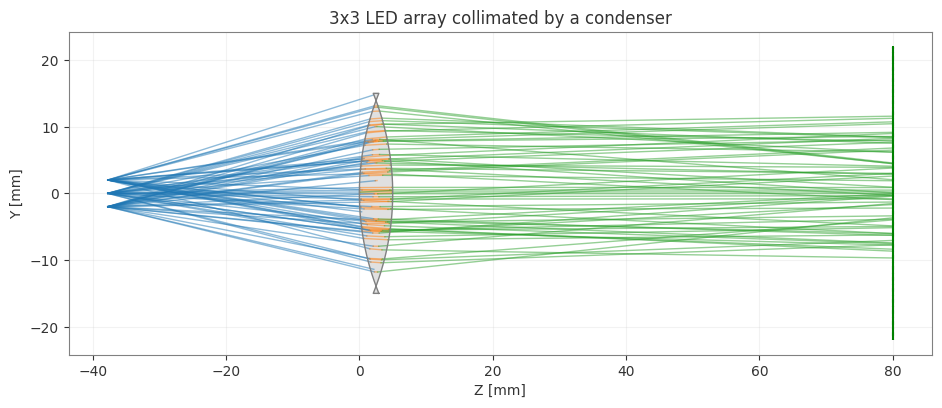

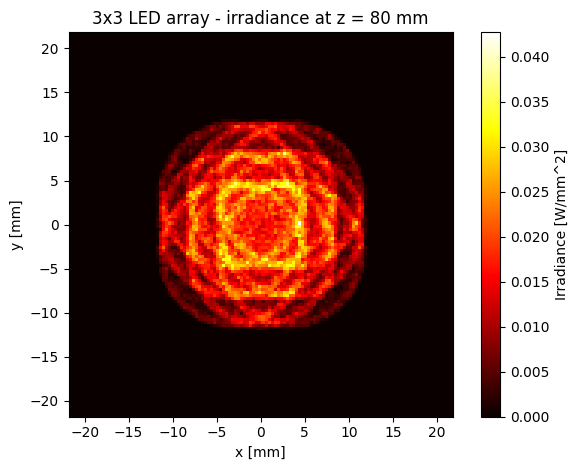

In [2]:
pitch = 2.0  # mm between LEDs
scene_array = NSQScene()

# 3x3 grid of LEDs at the condenser's front focal plane
for i, x in enumerate(np.linspace(-pitch, pitch, 3)):
    for j, y in enumerate(np.linspace(-pitch, pitch, 3)):
        scene_array.add_source(
            f'LED_{i}_{j}',
            CoordinateSystem(x=x, y=y, z=CONDENSER_FRONT_FOCUS),
            PointSourceConfig(
                spectrum=spec_w, total_flux=1.0, half_angle_deg=20,
            ),
        )

# Condenser lens: collimates each LED into its own tilted bundle
scene_array.add_lens('L', CoordinateSystem(z=0), CONDENSER)

# Detector in the collimated space downstream of the condenser
scene_array.add_detector(
    'D', CoordinateSystem(z=80),
    IrradianceDetectorConfig(width=44, height=44, num_pixels_x=128, num_pixels_y=128),
)

result_array = scene_array.trace(num_rays=90_000, seed=42)
irr_array = result_array.detectors['D']

print(f"Total sources    : {len(scene_array.sources)}")
print(f"Total flux in    : {result_array.total_flux_in:.2f} W")
print(f"Flux detected    : {irr_array.total_flux:.3f} W "
      f"({100 * irr_array.total_flux / result_array.total_flux_in:.0f}% collected)")
print(f"Flux escaped     : {result_array.total_flux_escaped:.3f} W")

scene_array.view(num_rays=80, color_by='bounce',
                 title='3x3 LED array collimated by a condenser')
plt.show()

fig = irr_array.plot(cmap='hot')
plt.title('3x3 LED array - irradiance at z = 80 mm')
plt.tight_layout()
plt.show()
plt.close(fig)


## 2. Illumination Uniformity Analysis

A key figure of merit for illumination systems is **uniformity** — how evenly the
flux is distributed across the target. Common metrics:

- **Uniformity ratio** = min / max irradiance
- **RMS uniformity** = 1 − σ / μ
- **±X% area** = fraction of pixels within X% of the mean

All of them are computed over the *lit* region, so they are only as meaningful as
the definition of "lit". The 1%-of-peak threshold used below is a convention, not
a law; a scene where stray unfocused light reaches the detector will drag the
threshold down and flatter the numbers.


Uniformity (min/max)  : 0.010
RMS uniformity (1-σ/μ): 0.445
Pixels within ±20% μ  : 24.9%


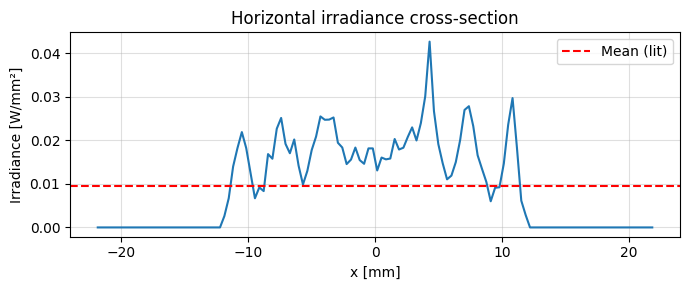

In [3]:
E = irr_array.irradiance
# Only consider lit pixels (above 1% of peak)
lit = E > 0.01 * E.max()
E_lit = E[lit]

uniformity_min_max = E_lit.min() / E_lit.max()
rms_uniformity     = 1.0 - E_lit.std() / E_lit.mean()
within_20pct       = np.mean(np.abs(E_lit - E_lit.mean()) < 0.20 * E_lit.mean()) * 100

print(f"Uniformity (min/max)  : {uniformity_min_max:.3f}")
print(f"RMS uniformity (1-σ/μ): {rms_uniformity:.3f}")
print(f"Pixels within ±20% μ  : {within_20pct:.1f}%")

# Horizontal profile
ny, nx = E.shape
row_centre = E[ny // 2, :]

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(irr_array.x_coords, row_centre)
ax.axhline(row_centre.mean(), color='r', linestyle='--', label='Mean (lit)')
ax.set_xlabel('x [mm]')
ax.set_ylabel('Irradiance [W/mm²]')
ax.set_title('Horizontal irradiance cross-section')
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()
plt.close(fig)

## 3. Off-Axis and Tilted Sources

Tilt a source by setting `rx` and `ry` in the `CoordinateSystem` (values in
**radians**). This lets you model off-axis field angles or oblique illumination.

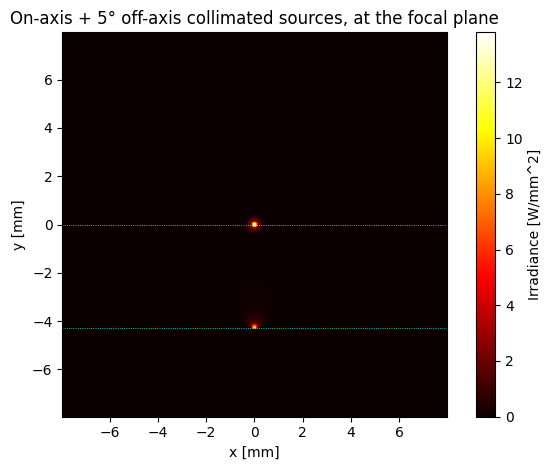

Predicted off-axis spot: y = -f*tan(5°) = -4.29 mm


In [4]:
scene_tilt = NSQScene()

# On-axis source
scene_tilt.add_source(
    'S_on', CoordinateSystem(z=-80),
    CollimatedSourceConfig(spectrum=spec_green, total_flux=1.0, aperture_radius=8.0),
)
# 5-degree tilted source (field angle)
scene_tilt.add_source(
    'S_off', CoordinateSystem(z=-80, rx=np.radians(5)),
    CollimatedSourceConfig(spectrum=spec_green, total_flux=1.0, aperture_radius=8.0),
)

scene_tilt.add_lens('L', CoordinateSystem(z=0), SINGLET)

# Both sources are collimated, so both focus at the rear focal plane. The
# tilted one lands off axis at -f*tan(5 deg) = -4.3 mm; that separation is the
# whole point of the figure, and it vanishes into a common blur if the
# detector is anywhere else.
scene_tilt.add_detector(
    'D', CoordinateSystem(z=SINGLET_REAR_FOCUS),
    IrradianceDetectorConfig(width=16, height=16, num_pixels_x=192, num_pixels_y=192),
)

result_tilt = scene_tilt.trace(num_rays=120_000, seed=42)
irr_tilt = result_tilt.detectors['D']

fig = irr_tilt.plot(cmap='hot')
plt.axhline(0.0, color='cyan', lw=0.6, ls=':')
plt.axhline(-49.05 * np.tan(np.radians(5)), color='cyan', lw=0.6, ls=':')
plt.title('On-axis + 5\u00b0 off-axis collimated sources, at the focal plane')
plt.tight_layout()
plt.show()
plt.close(fig)

print(f"Predicted off-axis spot: y = -f*tan(5\u00b0) = "
      f"{-49.05 * np.tan(np.radians(5)):+.2f} mm")


## 4. Mixed-Spectrum Sources

Each source can have an independent `Spectrum`. Here three point sources at
different wavelengths and different heights are imaged by the singlet.

Placing them 100 mm in front of the lens — roughly twice the focal length —
puts the image near z = 87 mm at a magnification of about −0.84, so the three
sources arrive as three resolved, inverted spots.

One caveat worth stating plainly: an `IrradianceMap` records **total** flux per
pixel, with no wavelength axis. It cannot show colour. To separate the three
wavelengths you need a `SpectralDetector`, which bins flux by wavelength — see
notebook 04.


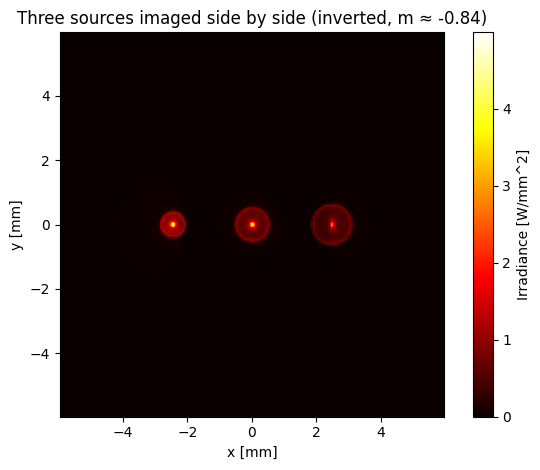

Total flux in    : 3.0000 W  (3 sources × 1 W each)
Flux on detector : 2.5793 W

Source x = -3.0, 0.0, +3.0 mm  ->  image x ≈ +2.5, 0.0, -2.5 mm


In [5]:
spec_r = Spectrum.monochromatic(0.64)   # red
spec_g = Spectrum.monochromatic(0.532)  # green
spec_b = Spectrum.monochromatic(0.45)   # blue

scene_rgb = NSQScene()

# Three point sources at 3 mm separation, each a different colour. The 8-degree
# cone fills the 15 mm lens from 100 mm away without spilling past it.
for name, spec, x in [('R', spec_r, -3.0), ('G', spec_g, 0.0), ('B', spec_b, 3.0)]:
    scene_rgb.add_source(
        name, CoordinateSystem(x=x, z=-100),
        PointSourceConfig(spectrum=spec, total_flux=1.0, half_angle_deg=8),
    )

scene_rgb.add_lens('L', CoordinateSystem(z=0), SINGLET)
scene_rgb.add_detector(
    'D', CoordinateSystem(z=87),
    IrradianceDetectorConfig(width=12, height=12, num_pixels_x=192, num_pixels_y=192),
)

result_rgb = scene_rgb.trace(num_rays=120_000, seed=42)
irr_rgb = result_rgb.detectors['D']

fig = irr_rgb.plot(cmap='hot')
plt.title('Three sources imaged side by side (inverted, m \u2248 -0.84)')
plt.tight_layout()
plt.show()
plt.close(fig)

print(f"Total flux in    : {result_rgb.total_flux_in:.4f} W  (3 sources \u00d7 1 W each)")
print(f"Flux on detector : {irr_rgb.total_flux:.4f} W")
print("\nSource x = -3.0, 0.0, +3.0 mm  ->  image x \u2248 +2.5, 0.0, -2.5 mm")


## 5. Extended Source for Diffuse Illumination

An `ExtendedSource` uniformly samples positions on a rectangle. Put it at the
condenser's front focal plane and you have Köhler illumination: the source is
imaged to infinity, so the target sees an even wash of light rather than a
picture of the emitter.

The same aperture-filling rule applies. The original 45° cone from 50 mm away
would have thrown a 50 mm beam radius at a lens with a 15 mm semi-diameter,
sending roughly nine tenths of the light past the glass and onto the detector as
unfocused spill.


Collected: 3.798 W of 5.0 W (76%)
RMS uniformity over the lit area: 0.320


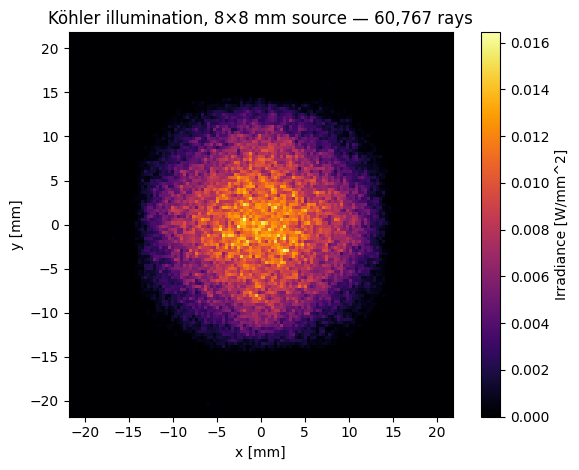

In [6]:
scene_ext = NSQScene()
scene_ext.add_source(
    'ES', CoordinateSystem(z=CONDENSER_FRONT_FOCUS),
    ExtendedSourceConfig(
        spectrum=spec_green, total_flux=5.0,
        width=8, height=8, half_angle_deg=20,
    ),
)
scene_ext.add_lens('L', CoordinateSystem(z=0), CONDENSER)
scene_ext.add_detector(
    'D', CoordinateSystem(z=80),
    IrradianceDetectorConfig(width=44, height=44, num_pixels_x=128, num_pixels_y=128),
)

result_ext = scene_ext.trace(num_rays=80_000, seed=0)
irr_ext = result_ext.detectors['D']

E_ext = irr_ext.irradiance
lit_ext = E_ext > 0.01 * E_ext.max()
print(f"Collected: {irr_ext.total_flux:.3f} W of {result_ext.total_flux_in:.1f} W "
      f"({100 * irr_ext.total_flux / result_ext.total_flux_in:.0f}%)")
print(f"RMS uniformity over the lit area: "
      f"{1 - E_ext[lit_ext].std() / E_ext[lit_ext].mean():.3f}")

fig = irr_ext.plot(cmap='inferno')
plt.title(f'K\u00f6hler illumination, 8\u00d78 mm source \u2014 {irr_ext.num_rays_hit:,} rays')
plt.tight_layout()
plt.show()
plt.close(fig)


## Summary

- Add as many sources as needed — all participate in the same trace
- Source position: `CoordinateSystem(x, y, z)` in mm
- Source tilt: `CoordinateSystem(rx=..., ry=...)` in radians
- Each source can have an independent `Spectrum` and `total_flux`
- `total_flux_in` in `SimulationResult` sums across all sources
- Analyse uniformity via `irradiance.min/max/std/mean` on the `IrradianceMap`

Two habits carry across every illumination model in this notebook:

- **Match the source cone to the aperture.** Light that misses the optic still
  reaches the detector, where it inflates the collected flux and corrupts every
  uniformity metric computed from the map.
- **Place sources and detectors by the prescription, not by eye.** A condenser
  collimates only from its front focal point; a collimated beam focuses only at
  the rear focal plane. Check `total_flux_escaped` and
  `flux_conservation_error` before trusting any number that comes out.
